<a href="https://colab.research.google.com/github/ceremona/nnsight_benchmarks/blob/main/nnsight_benchmarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NNsight tests — Visualized

Ablate a layer, see what changes. Interpretability with visuals, not print statements.

**Setup:** Runtime → Change runtime type → T4 GPU, then run top to bottom.

In [ ]:
!pip install -U nnsight

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.5/272.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 7.6 MB/s eta 0:00:00


## 1. Imports + model load

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from nnsight import LanguageModel

model = LanguageModel('openai-community/gpt2', device_map='auto', dispatch=True)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## 2. Config + helpers

Set the prompt and which layer to ablate. `s2d` normalizes nnsight output (may be tuple or 3D) to clean 2D `[seq, hidden]`.

In [ ]:
  prompt = "The Eiffel Tower is in the city of"
n_layers = len(model.transformer.h)   # 12 for GPT-2 small
ablate_layer = 5                       # which layer to zero out

def s2d(t):
    """Squeeze batch dim, unwrap tuples, detach from grad graph → 2D [seq, hidden]."""
    if isinstance(t, tuple):
        t = t[0]
    return t[0].detach() if t.dim() == 3 else t.detach()

## 3. Baseline trace

Run the model unmodified. Capture every layer's output + final logits.

## 4. Ablated trace

Zero out layer `ablate_layer`'s output. The disruption propagates through all subsequent layers.

In [ ]:
def run_trace(prompt, ablate_layer=None):
    """Run a trace, optionally ablating one layer. Returns (layer_outputs, logits)."""
    with model.trace(prompt):
        layers = list().save()  # save the list itself
        for i, h in enumerate(model.transformer.h):
            if ablate_layer is not None and i == ablate_layer:
                h.output[0][:] = 0  # ablate at the right point in the loop
            layers.append(h.output[0])
        logits = model.lm_head.output.save()
    return layers, logits

# Baseline (no ablation)
baseline, baseline_logits = run_trace(prompt, ablate_layer=None)

# Ablated (zero out layer 5)
ablated, ablated_logits = run_trace(prompt, ablate_layer=ablate_layer)

# Sanity check
print(f"baseline: {len(baseline)} layers, shape={s2d(baseline[0]).shape}")
print(f"ablated:  {len(ablated)} layers, ablated[5].sum()={s2d(ablated[5]).sum().item():.4f}")
print(f"baseline pred: {model.tokenizer.decode(s2d(baseline_logits)[-1].argmax())!r}")
print(f"ablated pred:  {model.tokenizer.decode(s2d(ablated_logits)[-1].argmax())!r}")

baseline: 12 layers, shape=torch.Size([10, 768])
ablated:  12 layers, ablated[5].sum()=0.0000
baseline pred: ' Paris'
ablated pred:  ' and'


## 5. Logit lens table

Project each layer's hidden states through the unembedding matrix → "what would the model predict if it stopped here?" Compare baseline vs ablated. ◀◀◀ marks where the prediction changed.

In [ ]:
unembed = model.lm_head.weight.detach()
tokens = model.tokenizer.encode(prompt)
token_strs = [model.tokenizer.decode([t]) for t in tokens]

def lens(hidden_2d):
    """Project [seq, hidden] through unembed → list of predicted tokens."""
    proj = hidden_2d @ unembed.T
    return [model.tokenizer.decode(proj[i].argmax()) for i in range(proj.shape[0])]

print(f"\n{'='*65}")
print(f"LOGIT LENS  |  prompt: {prompt!r}  |  ablated layer: {ablate_layer}")
print(f"{'='*65}")
print(f"{'Layer':>5} │ {'Baseline':>14} │ {'Ablated':>14} │ Changed?")
print("─" * 55)
for i in range(n_layers):
    b = lens(s2d(baseline[i]))[-1]
    a = lens(s2d(ablated[i]))[-1]
    flag = "  ◀◀◀" if b != a else ""
    print(f"{i:>5} │ {b:>14} │ {a:>14} │ {flag}")

bf = model.tokenizer.decode(s2d(baseline_logits)[-1].argmax())
af = model.tokenizer.decode(s2d(ablated_logits)[-1].argmax())
print("─" * 55)
print(f"{'FINAL':>5} │ {bf:>14} │ {af:>14} │")


LOGIT LENS  |  prompt: 'The Eiffel Tower is in the city of'  |  ablated layer: 5
Layer │       Baseline │        Ablated │ Changed?
───────────────────────────────────────────────────────
    0 │            the │            the │ 
    1 │            the │            the │ 
    2 │            the │            the │ 
    3 │            the │            the │ 
    4 │            the │            the │ 
    5 │            the │              ! │   ◀◀◀
    6 │            the │              , │   ◀◀◀
    7 │            the │            etc │   ◀◀◀
    8 │            the │            ind │   ◀◀◀
    9 │            the │           avia │   ◀◀◀
   10 │            the │            ind │   ◀◀◀
   11 │            the │            ind │   ◀◀◀
───────────────────────────────────────────────────────
FINAL │          Paris │            and │


## 6. Activation norm heatmaps

L2 norm of each layer's output at each token position. Left = baseline, middle = ablated, right = difference. Red dashed line = ablation layer. The diff panel shows exactly how far the disruption propagated.

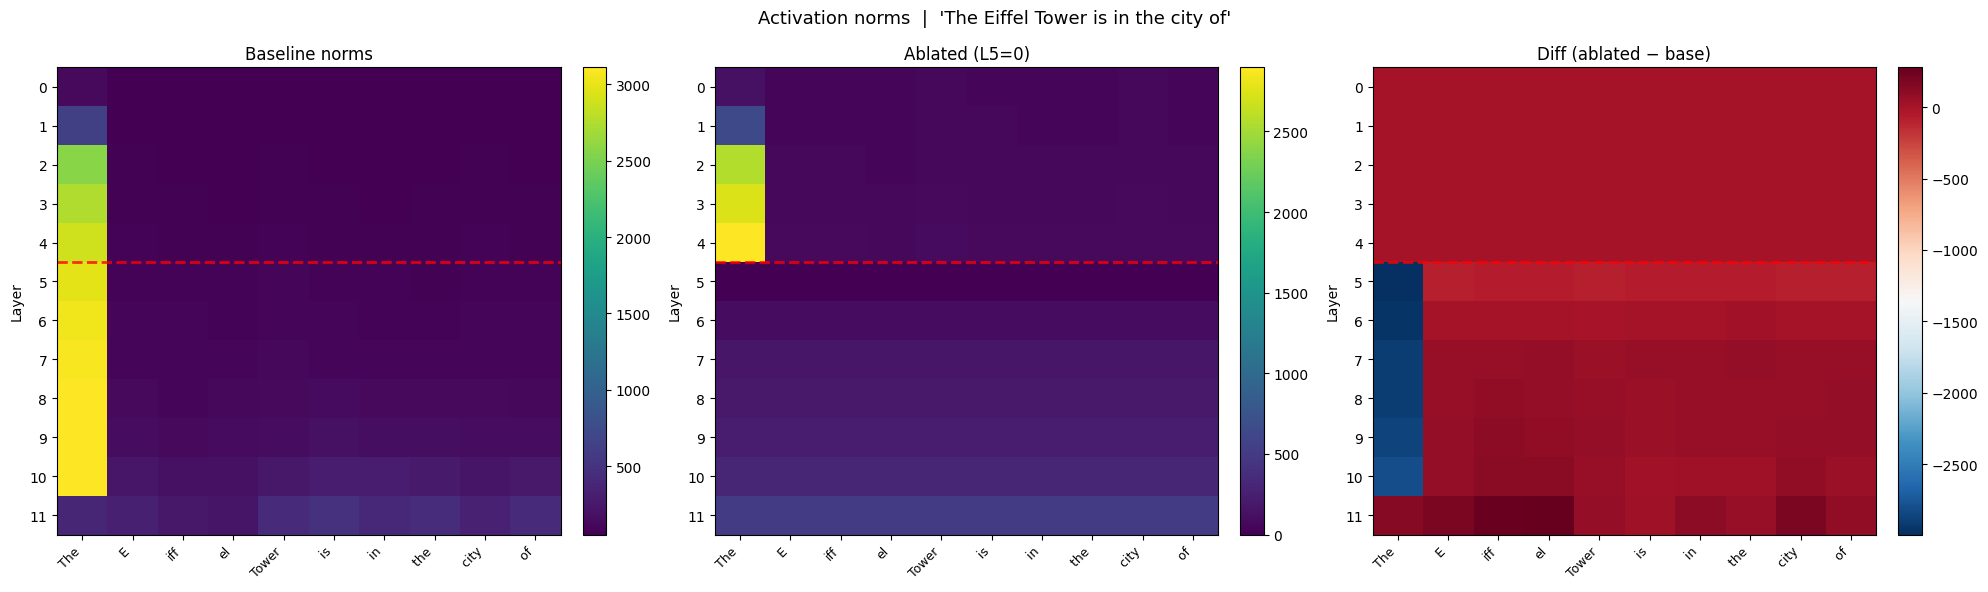

In [ ]:
base_norms = torch.stack([s2d(h).norm(dim=-1) for h in baseline]).cpu().numpy()
abla_norms = torch.stack([s2d(h).norm(dim=-1) for h in ablated]).cpu().numpy()
diff_norms  = abla_norms - base_norms

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, data, title, cmap in [
    (axes[0], base_norms, "Baseline norms",        "viridis"),
    (axes[1], abla_norms, f"Ablated (L{ablate_layer}=0)", "viridis"),
    (axes[2], diff_norms, "Diff (ablated − base)", "RdBu_r"),
]:
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(token_strs)))
    ax.set_xticklabels(token_strs, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_layers))
    ax.set_ylabel("Layer")
    ax.set_title(title)
    ax.axhline(y=ablate_layer - 0.5, color='red', ls='--', lw=2, alpha=0.8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle(f"Activation norms  |  {prompt!r}", fontsize=13)
plt.tight_layout(); plt.show()

## 7. Probability shift

Top-10 next-token predictions, baseline vs ablated. Shows whether the ablation actually changed the model's mind or just shuffled probability mass.

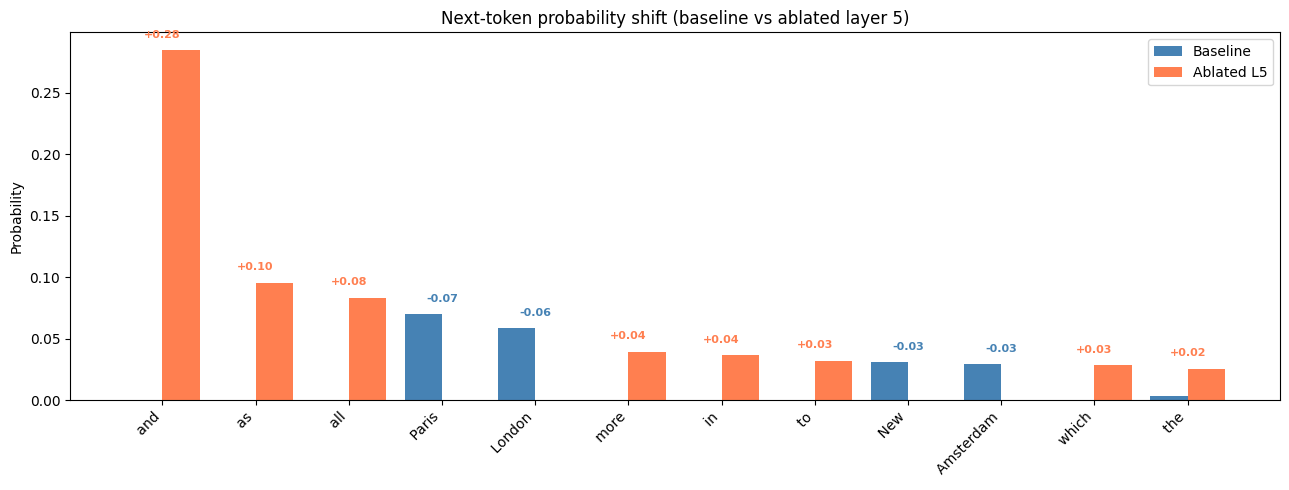

In [ ]:
bl = s2d(baseline_logits)[-1]
al = s2d(ablated_logits)[-1]
bp = torch.softmax(bl, dim=-1).cpu().numpy()
ap = torch.softmax(al, dim=-1).cpu().numpy()

# Sort by max probability across both conditions
max_probs = np.maximum(bp, ap)
top = np.argsort(max_probs)[-12:][::-1]
labels = [model.tokenizer.decode([i]) for i in top]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top)); w = 0.4
ax.bar(x - w/2, bp[top], w, label='Baseline', color='steelblue')
ax.bar(x + w/2, ap[top], w, label=f'Ablated L{ablate_layer}', color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel("Probability")
ax.set_title(f"Next-token probability shift (baseline vs ablated layer {ablate_layer})")
ax.legend()

# Add delta indicators for tokens that actually moved
for i, idx in enumerate(top):
    delta = ap[idx] - bp[idx]
    if abs(delta) > 0.01:
        ax.annotate(f'{delta:+.2f}', xy=(i, max(bp[idx], ap[idx]) + 0.01),
                    ha='center', fontsize=8, fontweight='bold',
                    color='coral' if delta > 0 else 'steelblue')
plt.tight_layout(); plt.show()

## 8. Layer importance sweep

Ablate each layer one at a time, measure KL divergence from baseline. Reveals which layers are load-bearing for this specific prediction. In GPT-2 you'll typically see layers 8-11 do most of the work.

Layer  0 ablated → pred:                ,  KL: 4.9018
Layer  1 ablated → pred:              the  KL: 3.8482
Layer  2 ablated → pred:                .  KL: 12.7743
Layer  3 ablated → pred:                +  KL: 14.4813
Layer  4 ablated → pred:                -  KL: 14.2883
Layer  5 ablated → pred:              and  KL: 14.3053
Layer  6 ablated → pred:              and  KL: 14.3043
Layer  7 ablated → pred:                ,  KL: 11.3654
Layer  8 ablated → pred:                
  KL: 13.9573
Layer  9 ablated → pred:                ,  KL: 9.6944
Layer 10 ablated → pred:                .  KL: 9.5903
Layer 11 ablated → pred:                ,  KL: 3.9265


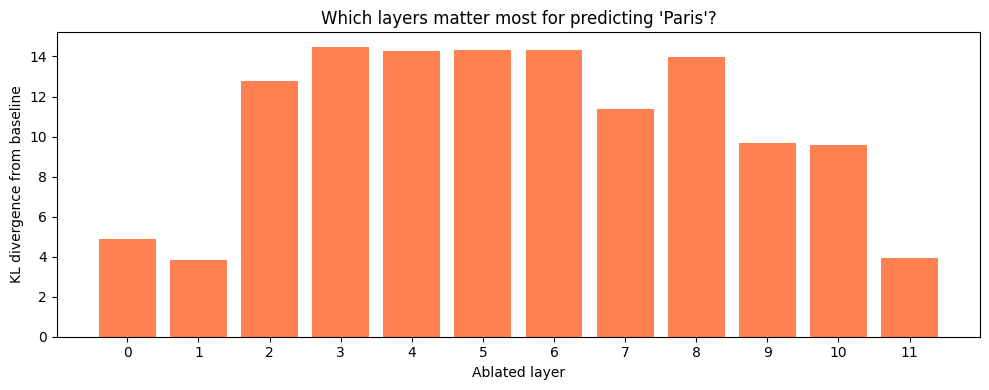

In [ ]:
base_probs = torch.softmax(s2d(baseline_logits)[-1], dim=-1).cpu().numpy()

kl_divs = []
for layer in range(n_layers):
    with model.trace(prompt):
        model.transformer.h[layer].output[0][:] = 0
        logits = model.lm_head.output.save()
    probs = torch.softmax(s2d(logits)[-1], dim=-1).cpu().numpy()
    kl = np.sum(base_probs * (np.log(base_probs + 1e-10) - np.log(probs + 1e-10)))
    kl_divs.append(kl)
    pred = model.tokenizer.decode(s2d(logits)[-1].argmax())
    print(f"Layer {layer:>2} ablated → pred: {pred:>16}  KL: {kl:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['coral' if k > 0.5 else 'steelblue' for k in kl_divs]
ax.bar(range(n_layers), kl_divs, color=colors)
ax.set_xlabel("Ablated layer"); ax.set_ylabel("KL divergence from baseline")
ax.set_title("Which layers matter most for predicting 'Paris'?")
ax.set_xticks(range(n_layers))
plt.tight_layout(); plt.show()

## Things to try

- Change `ablate_layer` in the Config cell and re-run to see different ablation effects
- Try position-specific ablation: `model.transformer.h[5].output[0][-1, :] = 0` (last token only)
- Try a different prompt and watch the layer importance sweep shift
- Swap the model: `LanguageModel('EleutherAI/pythia-160m', ...)` for a different architecture
- Cross-prompt activation patching: save layer N from prompt A, inject into prompt B's forward pass